# 1.0 Quadrotor Dynamics Model

The quadrotor state is 9-dimensional: $\mathbf{x} = [x, y, z, v_x, v_y, v_z, \phi, \theta, \psi]^T$.

Control inputs (4D): $\mathbf{u} = [\phi_c, \theta_c, v_{zc}, \dot{\psi}_c]^T$ — commanded roll, pitch, vertical velocity, yaw rate.

The continuous-time dynamics use a **first-order low-pass Euler approximation** of the Parrot Bebop 2 model.

## Velocity Dynamics

$$\dot{\mathbf{v}} = \mathbf{R}_Z(\psi)\begin{bmatrix}g\tan\theta \\ -g\tan\phi\end{bmatrix} - k_D\mathbf{v}$$

where $\mathbf{R}_Z(\psi)$ is the 2D rotation matrix about the z-axis.

## Attitude Dynamics (First-Order Lags)

$$\dot{\phi} = \frac{1}{\tau_\phi}(k_\phi\phi_c - \phi), \quad \dot{\theta} = \frac{1}{\tau_\theta}(k_\theta\theta_c - \theta), \quad \dot{\psi} = \dot{\psi}_c$$


All CC-MPC functions loaded and ready.


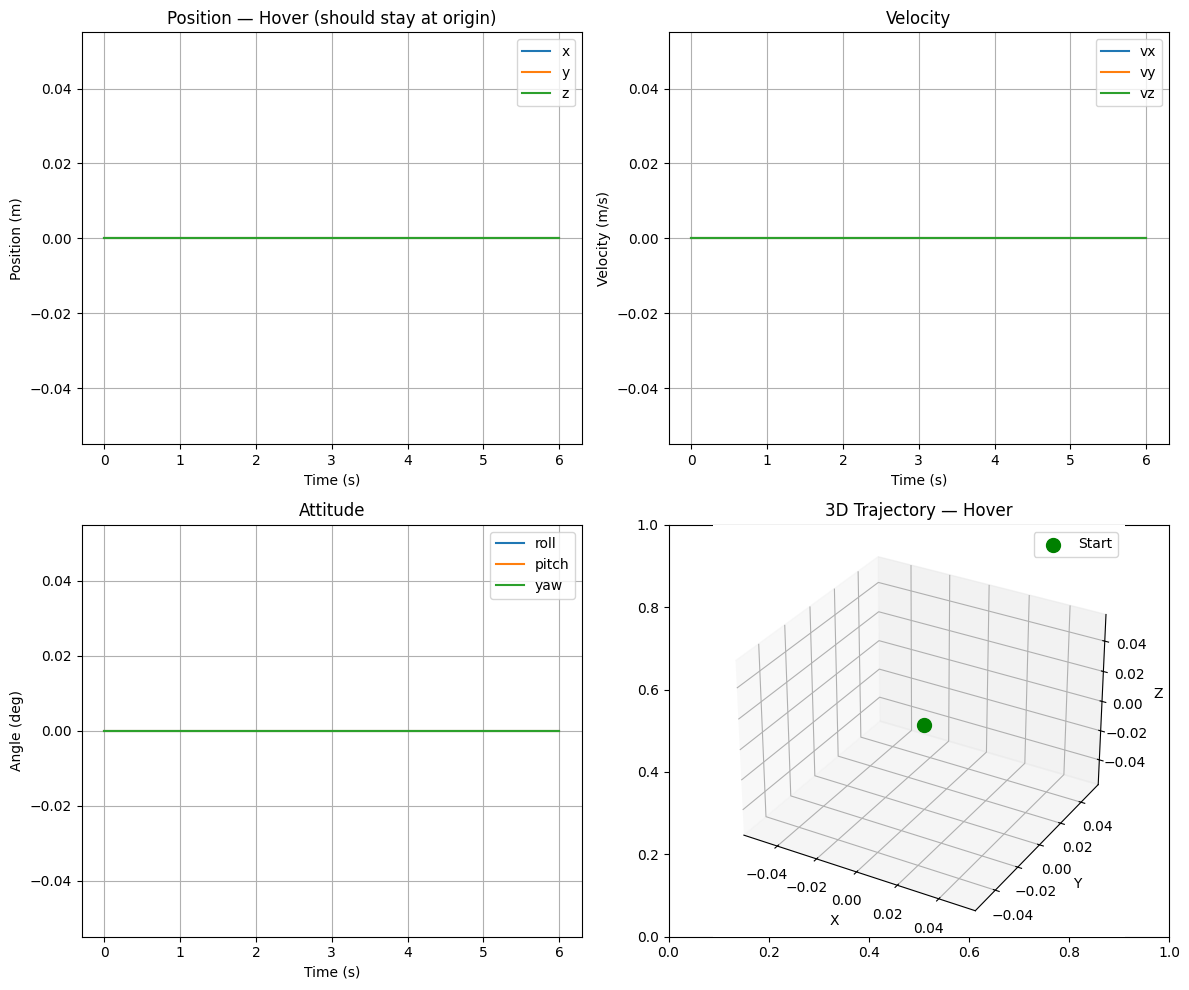

Hover: quadrotor stays at origin — equilibrium verified.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, tan, atan2, sqrt, pi, erf, exp
from numpy.linalg import norm

# ── Parameters ──
g, kD = 9.81, 0.5
k_phi, k_theta, k_vz = 1.0, 1.0, 3.0
tau_phi, tau_theta, tau_vz = 0.2, 0.2, 0.4

def continuous_dynamics(x, u):
    phi, theta, psi = x[6], x[7], x[8]
    phi_c, theta_c, vz_c, psi_dot_c = u
    F_theta, F_phi = tan(theta), tan(phi)
    A_tilt = sqrt(1 + F_theta**2 + F_phi**2)
    if A_tilt > 1e-12:
        F_theta /= cos(theta) * A_tilt
        F_phi /= cos(phi) * A_tilt
    dx = np.zeros(9)
    dx[0:3] = x[3:6]
    dx[3] = g * F_theta * cos(psi) - g * F_phi * sin(psi) - kD * x[3]
    dx[4] = g * F_theta * sin(psi) + g * F_phi * cos(psi) - kD * x[4]
    dx[5] = (k_vz * vz_c - x[5]) / tau_vz
    dx[6] = (k_phi * phi_c - phi) / tau_phi
    dx[7] = (k_theta * theta_c - theta) / tau_theta
    dx[8] = psi_dot_c
    return dx

def discrete_step(x, u, dt):
    f = lambda xk: continuous_dynamics(xk, u)
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def jacobian_state(x, u, eps=1e-6):
    n = len(x)
    J = np.zeros((n, n))
    for i in range(n):
        dx = np.zeros(n)
        dx[i] = eps
        fp = continuous_dynamics(x + dx, u)
        fm = continuous_dynamics(x - dx, u)
        J[:, i] = (fp - fm) / (2.0 * eps)
    return J

def jacobian_control(x, u):
    J = np.zeros((9, 4))
    J[6, 0] = k_phi / tau_phi
    J[7, 1] = k_theta / tau_theta
    J[5, 2] = k_vz / tau_vz
    J[8, 3] = 1.0
    return J

def linearize(x_bar, u_bar, dt):
    A_cont = jacobian_state(x_bar, u_bar)
    B_cont = jacobian_control(x_bar, u_bar)
    A_k = np.eye(9) + dt * A_cont
    B_k = dt * B_cont + 0.5 * dt * dt * (A_cont @ B_cont)
    x_next = discrete_step(x_bar, u_bar, dt)
    C_k = x_next - A_k @ x_bar - B_k @ u_bar
    return A_k, B_k, C_k

_SQRT_PI_INV = 0.5641895835477563

def erfinv(y, tol=1e-12):
    if abs(y) >= 1.0:
        return float('inf') if y > 0 else float('-inf')
    if y == 0.0:
        return 0.0
    sign = 1.0 if y > 0 else -1.0
    ya = abs(y)
    a_const = 0.147
    t = 2.0 / (pi * a_const) + np.log(1.0 - ya * ya) / 2.0
    x = sign * sqrt(sqrt(t * t - np.log(1.0 - ya * ya) / a_const) - t)
    for _ in range(50):
        fx = erf(x) - y
        if abs(fx) < tol:
            break
        d = 2.0 * _SQRT_PI_INV * exp(-x * x)
        if abs(d) < 1e-300:
            x += 0.1 if x >= 0.0 else -0.1
            continue
        x -= fx / d
    return x

def yaw_to_rotation(yaw):
    ct, st = cos(yaw), sin(yaw)
    return np.array([[ct, -st, 0.0], [st, ct, 0.0], [0.0, 0.0, 1.0]])

def box_to_ellipsoid_axes(size):
    return 0.5 * sqrt(3.0) * np.array(size)

def Omega_matrix(axes, radius, R_o):
    inv_sq = 1.0 / (axes + radius)**2
    return R_o.T @ np.diag(inv_sq) @ R_o

def chance_constraint_rhs(L, Sigma_mav, Sigma_obs, n_o, delta):
    Sigma_combined = Sigma_mav + Sigma_obs
    inner_cov = L @ Sigma_combined @ L.T
    sigma_scaled = sqrt(2.0 * n_o @ inner_cov @ n_o)
    return erfinv(1.0 - 2.0 * delta) * sigma_scaled

print("All CC-MPC functions loaded and ready.")

# ── Demo 1: Hover ──
dt = 0.06
x0 = np.zeros(9)
u = np.zeros(4)
steps = 100
traj = [x0.copy()]
for _ in range(steps):
    traj.append(discrete_step(traj[-1], u, dt))
traj = np.array(traj)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 0], label='x')
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 1], label='y')
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 2], label='z')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Position (m)')
axes[0, 0].set_title('Position — Hover (should stay at origin)'); axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 3], label='vx')
axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 4], label='vy')
axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 5], label='vz')
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Velocity (m/s)')
axes[0, 1].set_title('Velocity'); axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 6]), label='roll')
axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 7]), label='pitch')
axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 8]), label='yaw')
axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Angle (deg)')
axes[1, 0].set_title('Attitude'); axes[1, 0].legend(); axes[1, 0].grid(True)

ax3d = fig.add_subplot(2, 2, 4, projection='3d')
ax3d.plot(traj[:, 0], traj[:, 1], traj[:, 2])
ax3d.scatter(*traj[0, :3], c='g', s=100, marker='o', label='Start')
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Z')
ax3d.set_title('3D Trajectory — Hover'); ax3d.legend()
plt.tight_layout()
plt.savefig('outputs/1.0_hover.png', dpi=100, bbox_inches='tight')
plt.show()
print("Hover: quadrotor stays at origin — equilibrium verified.")


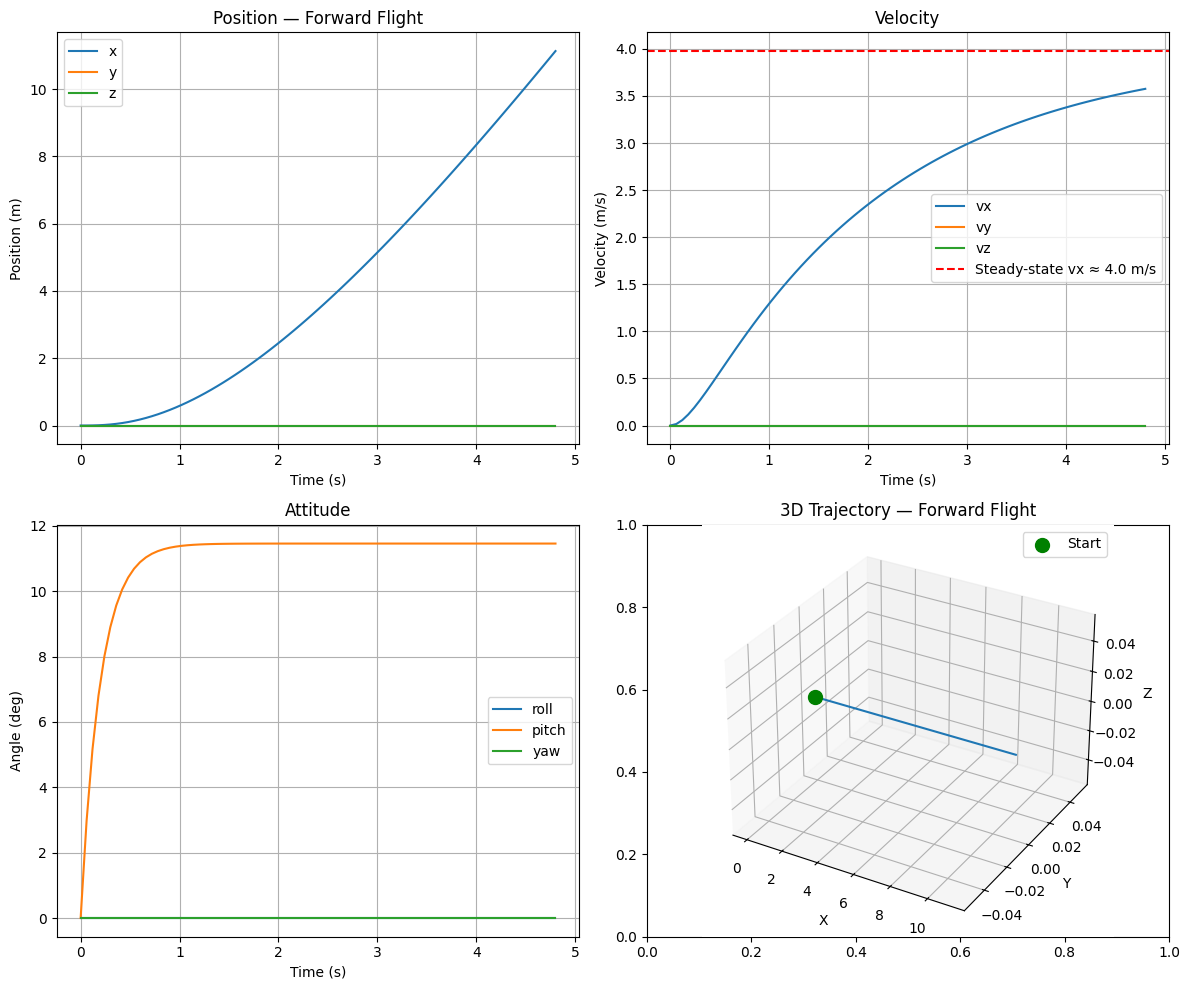

Forward flight: vx → 3.58 m/s (steady-state ≈ 4.0 m/s)


In [2]:

# ── Demo 2: Forward Flight (pitch = 0.2 rad ≈ 11.5°) ──
x0 = np.zeros(9)
u = np.array([0.0, 0.2, 0.0, 0.0])
steps = 80
traj = [x0.copy()]
for _ in range(steps):
    traj.append(discrete_step(traj[-1], u, dt))
traj = np.array(traj)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 0], label='x')
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 1], label='y')
axes[0, 0].plot(np.arange(steps+1)*dt, traj[:, 2], label='z')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Position (m)')
axes[0, 0].set_title('Position — Forward Flight'); axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 3], label='vx')
axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 4], label='vy')
axes[0, 1].plot(np.arange(steps+1)*dt, traj[:, 5], label='vz')
steady_vx = g * tan(0.2) / kD
axes[0, 1].axhline(steady_vx, color='r', linestyle='--', label=f'Steady-state vx ≈ {steady_vx:.1f} m/s')
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Velocity (m/s)')
axes[0, 1].set_title('Velocity'); axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 6]), label='roll')
axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 7]), label='pitch')
axes[1, 0].plot(np.arange(steps+1)*dt, np.rad2deg(traj[:, 8]), label='yaw')
axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Angle (deg)')
axes[1, 0].set_title('Attitude'); axes[1, 0].legend(); axes[1, 0].grid(True)

ax3d = fig.add_subplot(2, 2, 4, projection='3d')
ax3d.plot(traj[:, 0], traj[:, 1], traj[:, 2])
ax3d.scatter(*traj[0, :3], c='g', s=100, marker='o', label='Start')
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Z')
ax3d.set_title('3D Trajectory — Forward Flight'); ax3d.legend()
plt.tight_layout()
plt.savefig('outputs/1.0_forward.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Forward flight: vx → {traj[-1,3]:.2f} m/s (steady-state ≈ {steady_vx:.1f} m/s)")


## Summary

- **9D state, 4D control** — under-actuated system
- **RK4 integration** — 4th-order accuracy for dynamics
- **Hover is equilibrium** — x stays at origin with zero control
- **Pitch → forward velocity** — coupling through gravity
- **Drag limits speed** — steady-state $v_x = g\tan\theta / k_D$

**Next**: [[1.1 Linearization]]